<img src="../assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Exercise - `pandas` Data Transformation

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

## Part A: Load and Clean

#### 1. Load `College.csv`

- The first column doesn't have an accurate name, rename it.

In [2]:
# Your code here 
college = pd.read_csv('./data/College.csv')
college = college.rename(columns = {'Unnamed: 0': 'College'})
college.head()

,College,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


#### 2. Check the shape, the data types of each column, and the number of missing values per column

In [3]:
# Your code here
college.shape

(777, 19)

#### 3. Fix the `PhD` column

- `PhD` is the percentage of faculty with a PhD, but it has inaccurate entries.
- Fix the column and fill these entries with the plausible values.

In [4]:
# Your code here 
college['PhD'] = pd.to_numeric (college['PhD'], errors = 'coerce')
college.loc[college['PhD'] > 100, 'PhD'] = 100
college['PhD'] = college['PhD'].fillna(college['PhD'].median())

#### 4. Fix the `Grad.Rate` column

- `Grad.Rate` is the graduation rate, but it has data entry errors.

In [5]:
# Your code here
college.loc[college['Grad.Rate'] > 100, 'Grad.Rate'] = 100 

## Part B: Diagnose, Transform, and Visualize Skew

#### The tables bellow can be used as a reference to classify the the degree and distribution of the skewness as well as the right distribution transformation method.

### Table1: Skewness Score Interpretation

| Skewness Score Range | Distribution Shape | 
| :--- | :--- | 
| **Less than -1** | Highly Skewed (Left) | 
| **Between -1 and -0.5** | Moderately Skewed (Left) | 
| **Between -0.5 and 0.5** | `Normal (Symmetrical)` | 
| **Between 0.5 and 1** | Moderately Skewed (Right) | 
| **Greater than 1** | Highly Skewed (Right) | 

### Table2: Decision Matrix: Choosing the Right Distribution Transformation

| Transformation | Best Data Shape / Scenario | Handles Zeros? | Handles Negatives? | Impact on Linear Models / Interpretability |
| :--- | :--- | :--- | :--- | :--- |
| **Log Plus One ($\log(x+1)$)** | Highly Right-Skewed with zero counts |  Yes | ❌ No | Safely maps zero values to zero while retaining standard log-compression benefits. |
| **Box-Cox** | Right or Left Skewed (Strictly positive) | ❌ No | ❌ No | Automatically searches for the mathematically ideal power exponent ($\lambda$) to maximize normality. |
| **Yeo-Johnson** | Right or Left Skewed (Versatile) |  Yes |  Yes | Modifies the Box-Cox algorithm to safely calculate ideal power scales across zeros and negatives. |

#### 5. Write `skew_calc()` with `%%writefile`, then `plot_transformations()` here

- `skew_calc(df)`: for every numeric column, calculate its skewness, classify the degree and direction, and recommend a transformation. Use `%%writefile` to save this into `myutils.py`, then import it.
- `plot_transformations(df, skew_table)`: take a DataFrame together with the output of `skew_calc()`, apply the **best** recommended transformation to each column, and plot the before and after distributions side by side with the skewness labeled on each subplot.

In [6]:
%%writefile myutils.py
import pandas
import numpy as np
def skew_calc(df):
    """
    Diagnoses skewness for every numeric column in a DataFrame and recommends a transformation based on the column's skewness and
    minimum value. Binary, encoded, and ID columns are excluded, since skewness isn't a meaningful for them.
    It returns a DataFrame with the following columns:
    Feature, Skewness, Degree, Direction, Recommended Transformation
    """
    # Your code here 
    results = []
    numeric_df = df.select_dtypes(include="number")

    for col in numeric_df.columns:
        if numeric_df[col].nunique() <= 2:
            continue  # skip binary/flag columns

        skew_val = numeric_df[col].skew()
        min_val = numeric_df[col].min()

        # Direction
        direction = 'Right' if skew_val > 0 else 'Left'

        # Degree
        if abs(skew_val) <= 0.5:
            degree = 'Normal'
        elif abs(skew_val) <= 1:
            degree = 'Moderately Skewed'
        else:
            degree = 'Highly Skewed'

        # Recommended transformation
        if degree == 'Normal':
            recommendation = 'None'
        elif min_val > 0:
            recommendation = 'Box-Cox'
        elif min_val == 0:
            recommendation = 'Log Plus One'
        else:
            recommendation = 'Yeo-Johnson'

        results.append({
            'Feature': col,
            'Skewness': skew_val,
            'Degree': degree,
            'Direction': direction,
            'Recommended Transformation': recommendation
        })

    skew_table= pandas.DataFrame(results)
    return skew_table
    

Overwriting myutils.py


In [7]:
# Now import the function from myutils
from myutils import skew_calc

In [8]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here
    for _, row in skew_table.iterrows():
        col = row['Feature']
        recommendation = row['Recommended Transformation']

        if recommendation == 'None':
            continue

        original = df[col]

        if 'Log' in recommendation:
            transformed = np.log1p(original)
        elif original.min() > 0:
            pt = PowerTransformer(method='box-cox')
            transformed = pt.fit_transform(df[[col]]).flatten()
        else:
            pt = PowerTransformer(method='yeo-johnson')
            transformed = pt.fit_transform(df[[col]]).flatten()

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].hist(original, bins=30, color='#d95f02', edgecolor='white')
        axes[0].set_title(f'{col} Before\nSkew={original.skew():.2f}')

        axes[1].hist(transformed, bins=30, color='#1b9e77', edgecolor='white')
        axes[1].set_title(f'{col} After\nSkew={pd.Series(transformed).skew():.2f}')

        plt.tight_layout()
        plt.show()



#### 6. Run the functions on your cleaned DataFrame

- Call `skew_calc()` and check the table, does the classification match what you expected for these features?
- Call `plot_transformations()`, is the change significant?

In [9]:
# Your code here
skew_calc(college)

,Feature,Skewness,Degree,Direction,Recommended Transformation
0,Apps,3.723750,Highly Skewed,Right,Box-Cox
1,Accept,3.417727,Highly Skewed,Right,Box-Cox
2,Enroll,2.690465,Highly Skewed,Right,Box-Cox
3,Top10perc,1.413217,Highly Skewed,Right,Box-Cox
4,Top25perc,0.259340,Normal,Right,None
5,F.Undergrad,2.610458,Highly Skewed,Right,Box-Cox
6,P.Undergrad,5.692353,Highly Skewed,Right,Box-Cox
7,Outstate,0.509278,Moderately Skewed,Right,Box-Cox
8,Room.Board,0.477356,Normal,Right,None
9,Books,3.485025,Highly Skewed,Right,Box-Cox


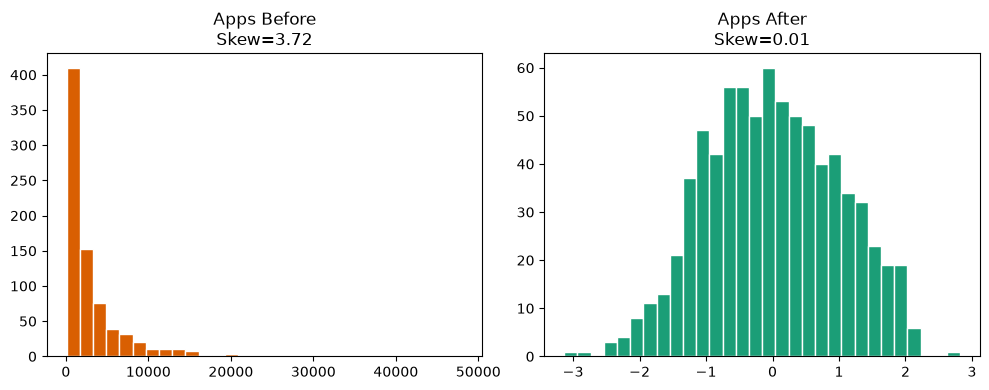

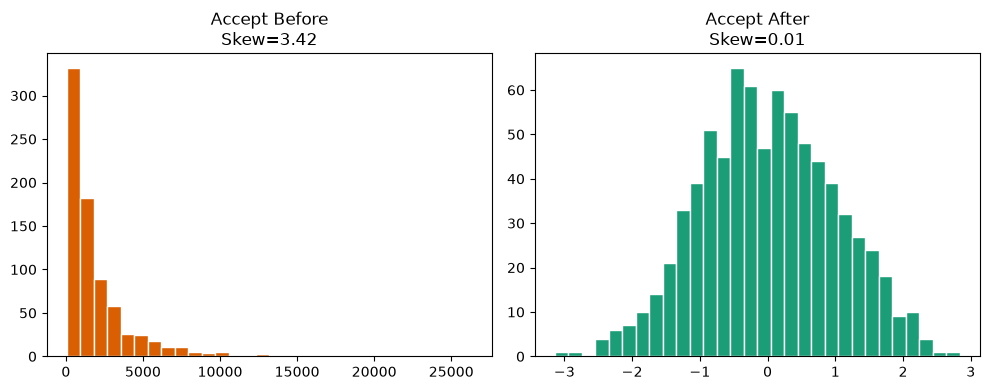

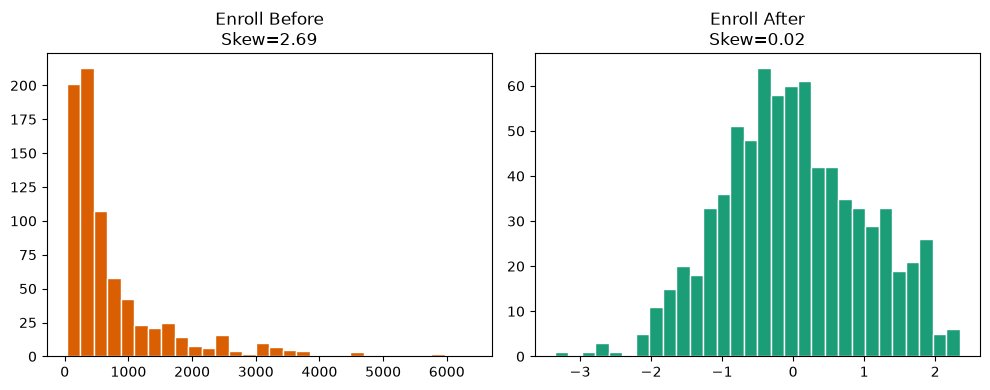

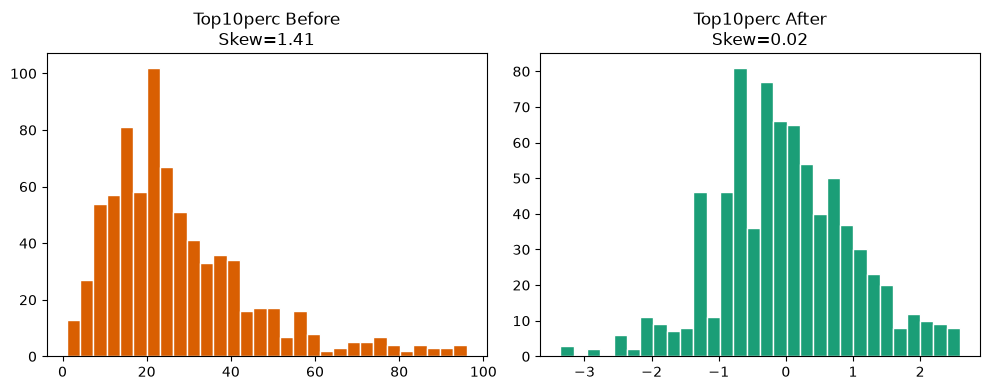

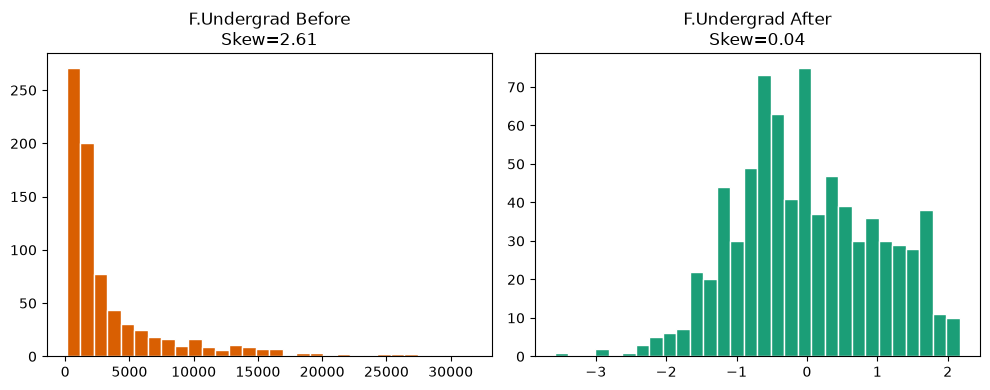

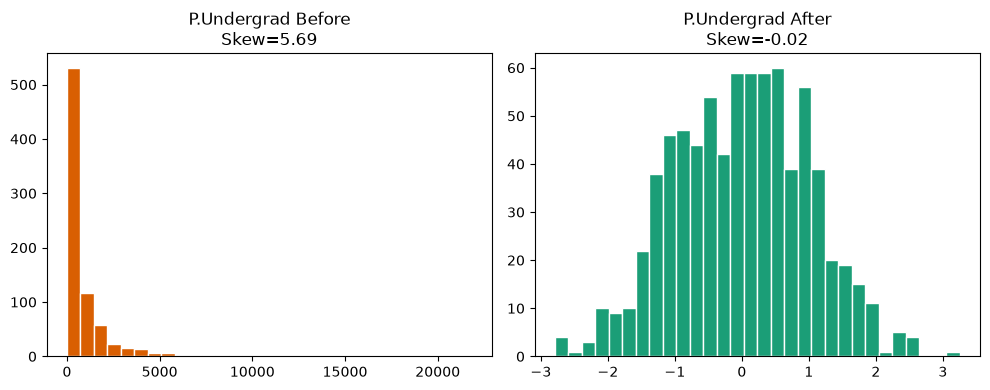

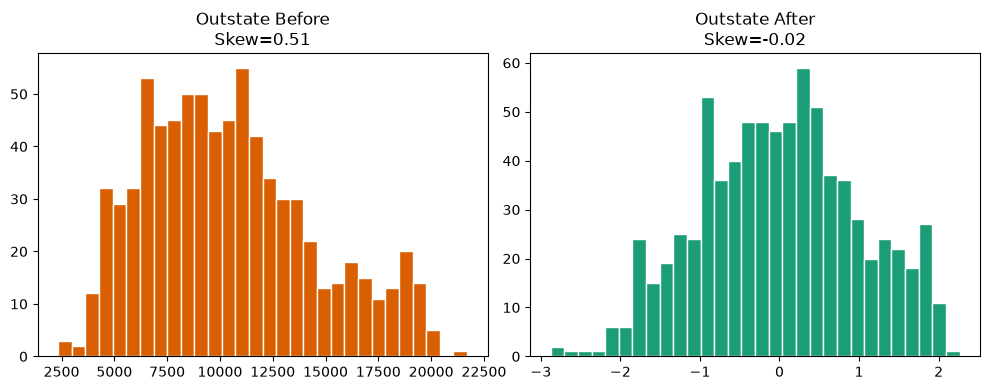

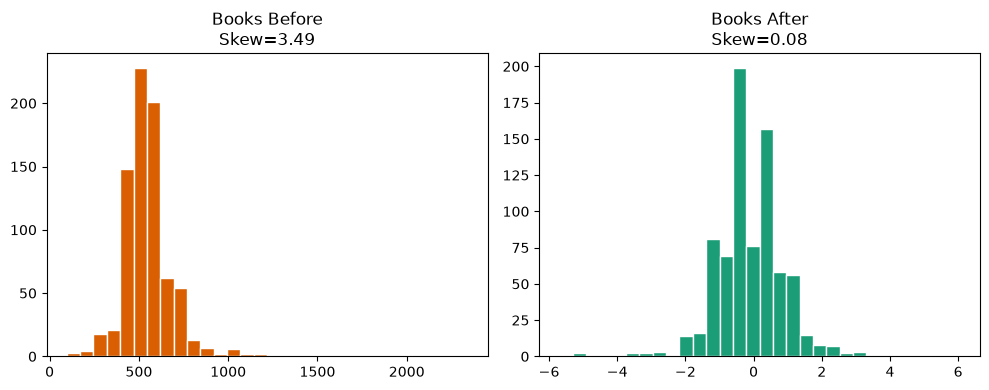

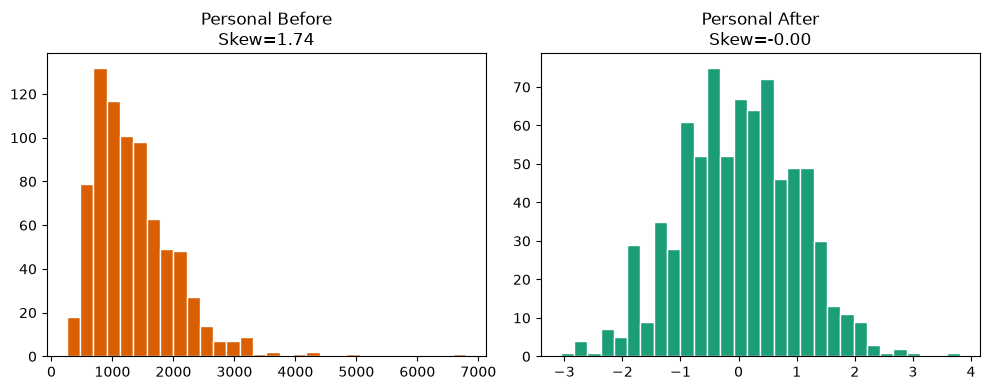

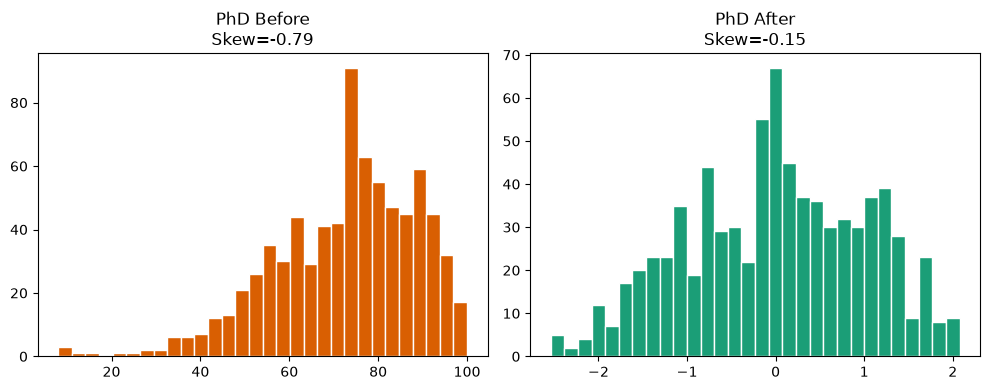

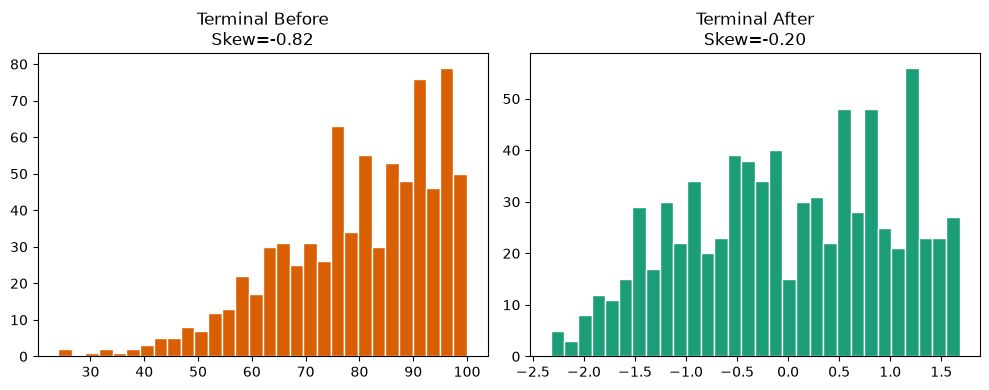

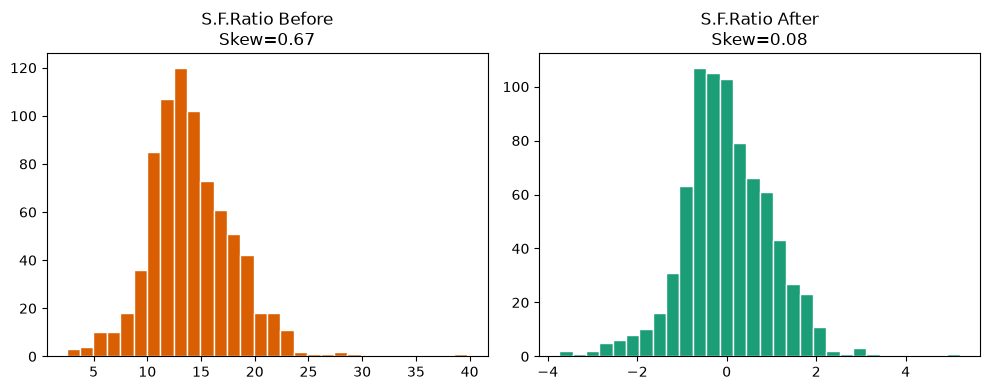

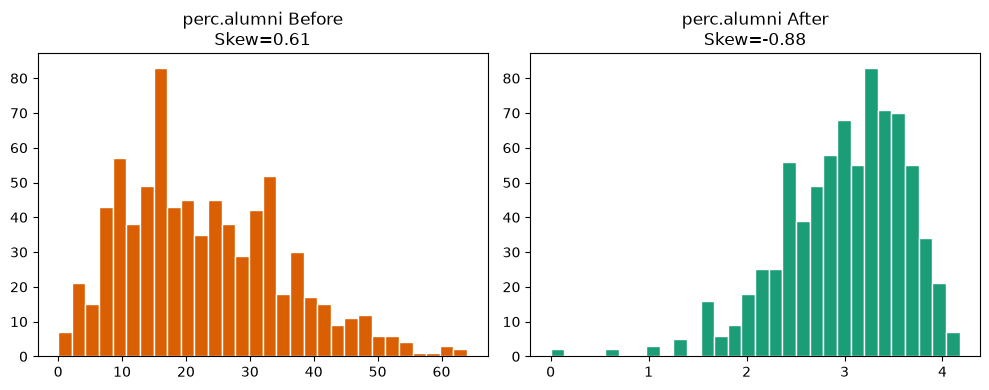

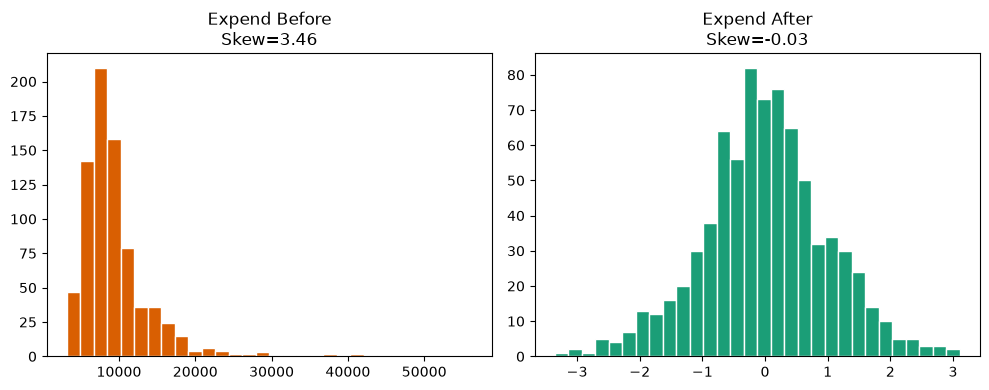

In [10]:
# Your code here
plot_transformations(college, skew_calc(college))

In [11]:
# Your code here


In [12]:
# No code here

## Part C: Apply the transformations

#### 7. Create transformed versions of the skewed columns

- Create a new column for each of the skewed columns based on the recommendations.

In [14]:
# trans_cols = []

# trans_cols
# Your code here 
trans_cols = []
skew_table = skew_calc(college)

for index, row in skew_table.iterrows():
    col = row['Feature']
    recommendation = row['Recommended Transformation']

    if recommendation == 'None':
        continue

    new_col = col + '_transformed'

    if 'Log' in recommendation:
        college[new_col] = np.log1p(college[col])
    elif college[col].min() > 0:
        college[new_col] = PowerTransformer(method='box-cox').fit_transform(college[[col]])
    else:
        college[new_col] = PowerTransformer(method='yeo-johnson').fit_transform(college[[col]])

    trans_cols.append(new_col)

trans_cols

['Apps_transformed',
 'Accept_transformed',
 'Enroll_transformed',
 'Top10perc_transformed',
 'F.Undergrad_transformed',
 'P.Undergrad_transformed',
 'Outstate_transformed',
 'Books_transformed',
 'Personal_transformed',
 'PhD_transformed',
 'Terminal_transformed',
 'S.F.Ratio_transformed',
 'perc.alumni_transformed',
 'Expend_transformed']

## Part D: Feature Engineering and Encoding

#### 8. Engineer a new feature called `Accept_Rate`

- An acceptance rate is more meaningful than the counts of applicants and accepted students on their own.

In [16]:
# Your code here 
college['Accept_Rate'] = college['Accept'] / college['Apps']
college['Accept_Rate']

0      0.742169
1      0.880146
2      0.768207
3      0.836930
4      0.756477
         ...   
772    0.689577
773    0.921388
774    0.913209
775    0.229145
776    0.620609
Name: Accept_Rate, Length: 777, dtype: float64

#### 9. Bin `Outstate` into a new column called `Outstate_Tier`

- Use `pd.cut()` to split out-of-state tuition into bins.

In [18]:
# Your code here
college['Outstate_Tier'] = pd.cut(
    college['Outstate'],
    bins=[0, 7000, 13000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

college['Outstate_Tier']

0      Medium
1      Medium
2      Medium
3      Medium
4      Medium
        ...  
772       Low
773    Medium
774       Low
775      High
776       Low
Name: Outstate_Tier, Length: 777, dtype: category
Categories (3, str): ['Low' < 'Medium' < 'High']

#### 10. Ordinally encode `Outstate_Tier`

- Create a new column that maps the tiers ordinally.

In [19]:
# Your code here
tier_map = {'Low': 0, 'Medium': 1, 'High': 2}
college['Outstate_Tier_encoded'] = college['Outstate_Tier'].map(tier_map)

#### 11. Binary encode `Private`

- Create a new coumn that maps `Yes` to 1 and `No` to 0.

In [41]:
# Your code here 

## Part E: Scale and Explore

#### 12. Standardize the transformed and encoded features

- Use `StandardScaler` on all transformed columns from question 7, plus the encoded features and store the results in new columns.

In [20]:
cols_to_scale = []
cols_to_scale = trans_cols + ['Accept_Rate', 'Outstate_Tier_encoded']

scaler = StandardScaler()
scaled_values = scaler.fit_transform(college[cols_to_scale])

scaled_cols = [col + '_scaled' for col in cols_to_scale]
college[scaled_cols] = scaled_values
# Your code here 

#### 13. Plot a correlation heatmap of your numeric features

- Include the scaled columns from question 12 along with other columns
- Which features look most related to `Grad.Rate`?
- Check and drop highly correlated features

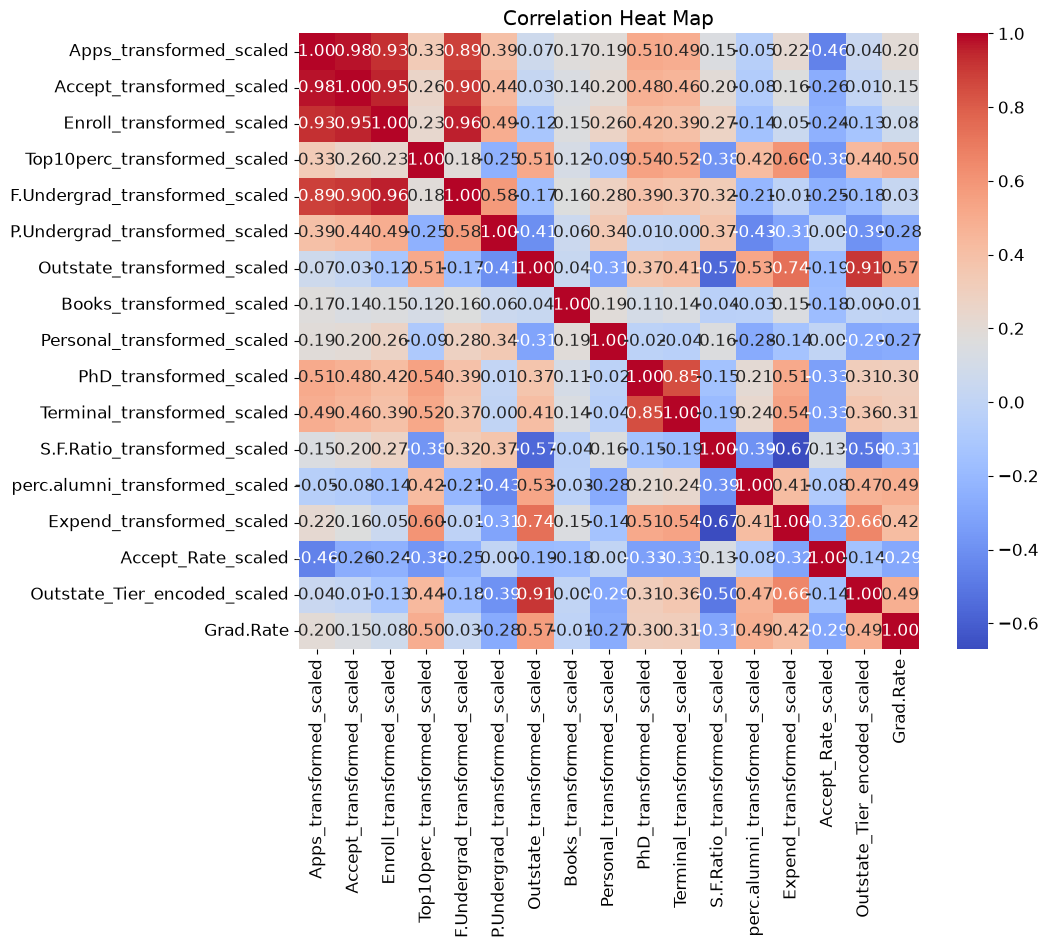

In [28]:
# Your code here 
scaled_cols_only = [c for c in college.columns if c.endswith('_scaled')]

corr = college[scaled_cols_only + ['Grad.Rate']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
plt.title('Correlation Heat Map')
plt.show()

## Part F: Does the Transformation Help?

#### 14. Split your data into train and test sets

- Train the model twice: once using the untransformed columns, and once using the transformed versions, so we can see whether the transformation actually improved the fit
- In both cases, the target will be `Grad.Rate`

In [29]:
# Your code here 
y = college['Grad.Rate'] 
untrans_predictors = ['Apps','Accept','Enroll','Top10perc','F.Undergrad','P.Undergrad',
                       'Outstate','Books','Personal','PhD','Terminal','S.F.Ratio',
                       'perc.alumni','Expend'] 
X= college[untrans_predictors]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#### 15. Fit a linear regression using the raw predictors


In [34]:
from sklearn.metrics import mean_squared_error
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print(f'mean_squared_error : {mean_squared_error(y_test, y_pred)**0.5}' )

mean_squared_error : 10.987397807578489


#### 16. Fit the same model using the log-transformed predictors

In [36]:
trans_predictors = []

# Your code here 
trans_predictors = [col + '_transformed' for col in untrans_predictors]
X_trans = college[trans_predictors]

X_train_trans, X_test_trans, y_train, y_test = train_test_split(X_trans, y, test_size=0.2, random_state=42)

lr_trans = LinearRegression()
lr_trans.fit(X_train_trans, y_train)
y_pred_trans = lr_trans.predict(X_test_trans)

print(f'mean_squared_error: {mean_squared_error(y_test, y_pred_trans)**0.5}')

mean_squared_error: 11.03101241686081


#### 17. Compare the two R-squared scores

- Is there an improvement in the results?

In [37]:
# Your code here 
r2_raw = lr.score(X_test, y_test)
r2_trans = lr_trans.score(X_test_trans, y_test)

print(f'Raw R2: {r2_raw}')
print(f'Transformed R2: {r2_trans}')

Raw R2: 0.4867280400826852
Transformed R2: 0.48264507386275324


#### 18. Export your cleaned and transformed `DataFrame` to a new CSV file called `college_transformed.csv`

In [48]:
# Your code here 

In [39]:
college.to_csv('./data/college_transformed.csv', index=False)